## Iniciate Collab on gdrive

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# cd '/content/drive/MyDrive/Brain_Matrix/S1_opto_Thal'

## Install neuron netpyne bluepysnap in the Google collab

In [3]:
# pip install pandas==1.5.3 numpy==1.23.5 neuron==8.2.2 netpyne==1.0.5

In [4]:
# !nrnivmodl mod2/

# NetPyNE

In [5]:
"""
cfg.py

High-level specifications for S1-thalamus network model using NetPyNE

Contributors: salvadordura@gmail.com, fernandodasilvaborges@gmail.com

# edges files not inclued in https://github.com/FernandoSBorges/
"""

from netpyne import specs
import json
import os
import numpy as np

%matplotlib inline

cfg = specs.SimConfig()

#------------------------------------------------------------------------------
#
# SIMULATION CONFIGURATION
#
#------------------------------------------------------------------------------

cfg.coreneuron = False

#------------------------------------------------------------------------------
# Select nodes to simulate
#------------------------------------------------------------------------------

f = open('cells_info_data.json')

Lista = json.load(f)

print(Lista)

cfg.hoclist = Lista["hoclist"]
cfg.Morpholist = Lista["Morpholist"]
cfg.gid_list = Lista["gid_list"]
# cfg.cellName_list = Lista["cellName_list"]
# cfg.cellsList = Lista["cellsList"]

cfg.Epops = []
cfg.Ipops = []

cfg.cellNumber = {}
cfg.popLabel = {}
cfg.popNumber = {}

cfg.cellNumber['L4_BP_cNAC_0'] = 1
# cfg.cellNumber['L4_BTC_cNAC_1'] = 1
# cfg.cellNumber['L4_NBC_cNAC_2'] = 1
# cfg.cellNumber['L4_SSC_cADpyr_3'] = 1
# cfg.cellNumber['L4_TPC_cADpyr_4'] = 1
# cfg.cellNumber['L4_TPC_cADpyr_5'] = 1
# cfg.cellNumber['L4_UPC_cADpyr_6'] = 1

for cellName in sorted(cfg.gid_list.keys())[0:1]:

    if 'cADpyr' in cellName:
        cfg.Epops.append(cellName)
    else:
        cfg.Ipops.append(cellName)

    cfg.popLabel[cellName] = cellName # No cell diversity in NetPyNE
    cfg.popNumber[cellName] = cfg.cellNumber[cellName]


print(cfg.cellNumber)
print(cfg.popNumber)



{'hoclist': {'108767': 'cNAC_L6NGC', '141766': 'cNAC_L6NGC', '138433': 'cNAC_L6NGC', '141369': 'cADpyr_L4TPC', '129252': 'cADpyr_L4TPC', '133426': 'cADpyr_L4TPC', '114284': 'cADpyr_L4UPC'}, 'Morpholist': {'108767': 'rp140319_ChC_3_idA_-_Scale_x1.000_y0.950_z1.000_-_Clone_1.asc', '141766': 'rp110127_L5-2_idG_-_Scale_x1.000_y0.950_z1.000.asc', '138433': 'rp110131_L5-1_idA_-_Scale_x1.000_y1.025_z1.000_-_Clone_0.asc', '141369': 'dend-rp120608_P_3_idD_axon-sm100429a1-5_INT_idG_-_Scale_x1.000_y1.050_z1.000_-_Clone_0.asc', '129252': 'dend-mtC050800E_idD_axon-sm100429a1-5_INT_idD_-_Scale_x1.000_y1.050_z1.000_-_Clone_0.asc', '133426': 'dend-mtC050800E_idD_axon-sm100429a1-5_INT_idD_-_Scale_x1.000_y0.975_z1.000_-_Clone_0.asc', '114284': 'dend-rp120803_P_1_idB_axon-C031097B-P3_-_Scale_x1.000_y0.975_z1.000_-_Clone_0.asc'}, 'gid_list': {'L4_BP_cNAC_0': 108767, 'L4_BTC_cNAC_1': 141766, 'L4_NBC_cNAC_2': 138433, 'L4_SSC_cADpyr_3': 141369, 'L4_TPC_cADpyr_4': 129252, 'L4_TPC_cADpyr_5': 133426, 'L4_UPC_cA

In [6]:
#------------------------------------------------------------------------------
# Run parameters
#------------------------------------------------------------------------------
cfg.duration = 1.2*1e3 ## Duration of the sim, in ms
cfg.dt = 0.025
cfg.seeds = {'cell': 4321, 'conn': 4321, 'stim': 1000, 'loc': 4321}
cfg.hParams = {'celsius': 34, 'v_init': -84.0}
cfg.verbose = False
cfg.createNEURONObj = True
cfg.createPyStruct = True
cfg.cvode_active = False
cfg.cvode_atol = 1e-6
cfg.cache_efficient = True
cfg.printRunTime = 0.1

cfg.includeParamsLabel = False
cfg.printPopAvgRates = True
cfg.checkErrors = False

#--------------------------------------------------------------------------
# Recording
#--------------------------------------------------------------------------
cfg.allpops = cfg.Epops + cfg.Ipops
cfg.recordCells = cfg.allpops # record all cells
cfg.recordTraces = {'V_soma': {'sec':'soma_0', 'loc':0.5, 'var':'v'},
                    'V_axon_0': {'sec':'axon_0', 'loc':0.5, 'var':'v'},
                    'i_axon_0_SK_E2_ik': {'sec':'axon_0', 'loc':0.5, 'mech':'SK_E2', 'var':'ik'},
                    # 'V_axon_1': {'sec':'axon_1', 'loc':0.5, 'var':'v'},
                    # 'V_myelin_0': {'sec':'myelin_0', 'loc':0.5, 'var':'v'},
                    # 'V_apic_0': {'sec':'apic_0', 'loc':0.5, 'var':'v'},
                    # 'V_dend_0': {'sec':'dend_0', 'loc':0.5, 'var':'v'},
                    # 'g_NMDA': {'sec': 'soma', 'loc': 0.5, 'synMech': 'NMDA', 'var': 'g'},
                    # 'i_GABAB': {'sec': 'soma', 'loc': 0.5, 'synMech': 'GABAB', 'var': 'i'}
                    }
cfg.recordStim = False
cfg.recordTime = False
cfg.recordStep = 0.025

# cfg.recordCurrents=True
# rec_curr = [('SK_E2','ik'),
            
#             ('TC_HH','ina'),('TC_HH','ik'),('TC_Nap_Et2','ina'),
#             ('TC_iA','ik'),('TC_iL','ica'),('TC_iT_Des98','ica'),('TC_ih_Bud97','ih')]
# if cfg.recordCurrents:
#     for curr in rec_curr: cfg.recordTraces.update({'i__soma_0__'+curr[0]+'__'+curr[1]:{'sec':'soma_0','loc':0.5,'mech':curr[0],'var':curr[1]},})


#  'Ih', 'K_Pst', 'K_Tst', 'NaTg', 'SK_E2', 'SKv3_1', 'pas'

#------------------------------------------------------------------------------
# Saving
#------------------------------------------------------------------------------
cfg.simLabel = 'v0_batch0'       #   + str(cfg.cynradNumber)
cfg.saveFolder = 'data/'+cfg.simLabel
# cfg.filename =                	## Set file output name
cfg.savePickle = True	        	## Save pkl file
cfg.saveJson = False           	## Save json file
cfg.saveDataInclude = ['simData', 'simConfig', 'net', 'netParams'] ## ['simData'] ##  ['simData'] ##, , 'simConfig', 'netParams'
cfg.backupCfgFile = None 		##
cfg.gatherOnlySimData = False	##
cfg.saveCellSecs = True
cfg.saveCellConns = True

#------------------------------------------------------------------------------
# Analysis and plotting
# ------------------------------------------------------------------------------
cfg.analysis['plotTraces'] = {'include': cfg.recordCells, 'oneFigPer': 'cell', 'overlay': True, 'timeRange': [400,1200], 'ylim': [-100,50], 'saveFig': False,
                              'showFig': False, 'figSize':(12,3)}
cfg.analysis['plotRaster'] = {'saveFig': False, 'showFig': False, 'orderInverse': True, 'timeRange': [500,1100], 'figSize': (12,5), 'popRates': True,
                              'fontSize':12, 'markerSize':4, 'marker': 'o', 'dpi': 100}


In [7]:
"""
netParams.py

High-level specifications for S1-thalamus network model using NetPyNE

Contributors: salvadordura@gmail.com, fernandodasilvaborges@gmail.com
"""

netParams = specs.NetParams()   # object of class NetParams to store the network parameters

#------------------------------------------------------------------------------
#
# NETWORK PARAMETERS
#
#------------------------------------------------------------------------------
cfg.reducedtest = False

for cellName in list(cfg.gid_list.keys())[0:1]:

        gid = cfg.gid_list[cellName]
        MorphoName = cfg.Morpholist[str(gid)]
        hocName = cfg.hoclist[str(gid)]
        MorphologyPath = 'O1_data_physiology/morphologies/ascii'

        print(cellName,hocName)

        cellRule = netParams.importCellParams(label=cellName, somaAtOrigin=True,
            conds={'cellType': cellName, 'cellModel': 'HH_full'},
            fileName='O1_data_physiology/emodels_hoc/' + hocName + '.hoc',
            cellName=hocName,
            cellInstance = False,
            cellArgs=[gid, MorphologyPath, MorphoName])


        axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, soma_pt3d_diam =  netParams.cellParams[cellName]['secs']['soma_0']['geom']['pt3d'][-1]

        netParams.cellParams[cellName]['secs']['axon_0']['geom']['diam'] = 5.0
        # netParams.cellParams[cellName]['secs']['axon_0']['geom']['L'] = 30.0

        axon_pt3d_diam =  netParams.cellParams[cellName]['secs']['axon_0']['geom']['diam']
        axon_pt3d_L =  netParams.cellParams[cellName]['secs']['axon_0']['geom']['L']

        netParams.cellParams[cellName]['secs']['axon_0']['geom']['pt3d'] = [(axon_pt3d_x, axon_pt3d_y, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L/2.0, axon_pt3d_z, axon_pt3d_diam),
                                                                                    (axon_pt3d_x, axon_pt3d_y+axon_pt3d_L, axon_pt3d_z, axon_pt3d_diam)]


        axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon_0_pt3d_diam =  netParams.cellParams[cellName]['secs']['axon_0']['geom']['pt3d'][-1]

        # netParams.cellParams[cellName]['secs']['axon_1']['geom']['diam'] = 2.5
        # netParams.cellParams[cellName]['secs']['axon_1']['geom']['L'] = 30.0

        axon1_pt3d_diam =  netParams.cellParams[cellName]['secs']['axon_1']['geom']['diam']
        axon1_pt3d_L =  netParams.cellParams[cellName]['secs']['axon_1']['geom']['L']

        netParams.cellParams[cellName]['secs']['axon_1']['geom']['pt3d'] = [(axon1_pt3d_x, axon1_pt3d_y, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L/2.0, axon1_pt3d_z, axon1_pt3d_diam),
                                                                                    (axon1_pt3d_x, axon1_pt3d_y+axon1_pt3d_L, axon1_pt3d_z, axon1_pt3d_diam)]


        myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, axon_1_pt3d_diam =  netParams.cellParams[cellName]['secs']['axon_1']['geom']['pt3d'][-1]

        # netParams.cellParams[cellName]['secs']['myelin_0']['geom']['diam'] = 0.5
        # netParams.cellParams[cellName]['secs']['myelin_0']['geom']['L'] = 100.0

        myelin_pt3d_diam =  netParams.cellParams[cellName]['secs']['myelin_0']['geom']['diam']
        myelin_pt3d_L =  netParams.cellParams[cellName]['secs']['myelin_0']['geom']['L']

        netParams.cellParams[cellName]['secs']['myelin_0']['geom']['pt3d'] = [(myelin_pt3d_x, myelin_pt3d_y, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L/2.0, myelin_pt3d_z, myelin_pt3d_diam),
                                                                                    (myelin_pt3d_x, myelin_pt3d_y+myelin_pt3d_L, myelin_pt3d_z, myelin_pt3d_diam)]
        
        #-----------------------------------------------------------------------------------#
        if cfg.reducedtest:
            cellRule = {'conds': {'cellType': cellName}, 'secs': {}}  # cell rule dict
            cellRule['conds'] = netParams.cellParams[cellName]['conds']    
            cellRule['secs'] = {}
            cellRule['secs']['soma_0'] = netParams.cellParams[cellName]['secs']['soma_0']
            cellRule['secs']['dend_0'] = netParams.cellParams[cellName]['secs']['dend_0']
            cellRule['secs']['dend_1'] = netParams.cellParams[cellName]['secs']['dend_1']
            cellRule['secs']['dend_2'] = netParams.cellParams[cellName]['secs']['dend_2']
            cellRule['secs']['dend_3'] = netParams.cellParams[cellName]['secs']['dend_3']
            cellRule['secs']['axon_0'] = netParams.cellParams[cellName]['secs']['axon_0']
            cellRule['secs']['axon_1'] = netParams.cellParams[cellName]['secs']['axon_1']
            cellRule['secs']['myelin_0'] = netParams.cellParams[cellName]['secs']['myelin_0']
            cellRule['secLists'] = {}
            cellRule['secLists']['somatic'] = ['soma_0']    
            cellRule['secLists']['spiny'] = ['soma_0', 'dend_0', 'dend_1', 'dend_2', 'dend_3']
            cellRule['secLists']['spinyEE'] = ['soma_0', 'dend_0', 'dend_1', 'dend_2', 'dend_3']
            cellRule['secLists']['all'] = ['soma_0', 'dend_0', 'axon_0', 'axon_1', 'myelin_0']
            cellRule['secLists']['axonal'] = ['axon_0', 'axon_1', 'myelin_0']
            cellRule['secLists']['basal'] = ['soma_0', 'dend_0', 'dend_1', 'dend_2', 'dend_3']   
            cellRule['secLists']['apical'] = ['soma_0', 'dend_0', 'dend_1', 'dend_2', 'dend_3']    
            netParams.cellParams[cellName] = cellRule   # add dict to list of cell params   
        #-----------------------------------------------------------------------------------#


# https://github.com/suny-downstate-medical-center/S1_mouse
# Layer	     height	  from	  to
# L1         0.089      0.000	0.089
# L2         0.070      0.089	0.159
# L3         0.128      0.159	0.286
# L4         0.134      0.286	0.421
# L5         0.263      0.421	0.684
# L6         0.316      0.684	1.000
# L23        0.198      0.089	0.286
# All     1378.8 um

layer = {'1':[0.0, 0.089], '2': [0.089,0.159], '3': [0.159,0.309], '23': [0.089,0.309], '4':[0.309,0.418], '5': [0.418,0.684], '6': [0.684,1.0],
'longS1': [2.2,2.3], 'longS2': [2.3,2.4]}  # normalized layer boundaries

#Th pop
ymin={'ss_RTN_o': 1688, 'ss_RTN_m': 1766, 'ss_RTN_i': 1844, 'VPL_sTC': 2000, 'VPM_sTC': 2156, 'POm_sTC_s1': 2312}
ymax={'ss_RTN_o': 1766, 'ss_RTN_m': 1844, 'ss_RTN_i': 2000, 'VPL_sTC': 2156, 'VPM_sTC': 2312, 'POm_sTC_s1': 2624}

#------------------------------------------------------------------------------
# General network parameters
#------------------------------------------------------------------------------
netParams.scale = 1.0 # Scale factor for number of cells
netParams.sizeX = 200.0 # x-dimension (horizontal length) size in um
netParams.sizeY = 2080.0 # y-dimension (vertical height or cortical depth) size in um
netParams.sizeZ = 200.0 # z-dimension (horizontal depth) size in um
netParams.shape = 'cylinder' # cylindrical (column-like) volume
netParams.rotateCellsRandomly = True

netParams.defaultThreshold = -20.0 # spike threshold, 10 mV is NetCon default, lower it for all cells
netParams.defaultDelay = 0.1 # default conn delay (ms)
netParams.propVelocity = 300.0 #  300 μm/ms (Stuart et al., 1997)
netParams.scaleConnWeightNetStims = 0.001  # weight conversion factor (from nS to uS)

#------------------------------------------------------------------------------
# S1 pop
#------------------------------------------------------------------------------
for cellName in netParams.cellParams.keys():
    layernumber = cellName[1:2]
    if layernumber == '2':
        netParams.popParams[cellName] = {'cellType': cellName, 'cellModel': 'HH_full', 'ynormRange': layer['23'],  'numCells':cfg.cellNumber[cellName]}
    else:
        netParams.popParams[cellName] = {'cellType': cellName, 'cellModel': 'HH_full', 'ynormRange': layer[layernumber], 'numCells': cfg.cellNumber[cellName]}


L4_BP_cNAC_0 cNAC_L6NGC


In [8]:
# netParams.cellParams[cellName]['secs']['soma_0']['geom']['diam']

In [9]:
netParams.cellParams['L4_BP_cNAC_0']['secs']['soma_0']['mechs'].keys()

dict_keys(['CaDynamics_DC0', 'Ca_HVA2', 'Ca_LVAst', 'Ih', 'K_Pst', 'K_Tst', 'NaTg', 'SK_E2', 'SKv3_1', 'pas'])

In [10]:
#------------------------------------------------------------------------------
# Current inputs
#------------------------------------------------------------------------------
cfg.addIClamp = True  # decrease the transient

cfg.IClamp = []
cfg.IClampnumber = 0

for pop in cfg.Epops:
  cfg.IClamp.append({'pop': pop, 'sec': 'soma_0', 'loc': 0.5, 'start': 500, 'dur': 600, 'amp': 0.2}) #pA
  cfg.IClampnumber=cfg.IClampnumber+1

for pop in cfg.Ipops:
  cfg.IClamp.append({'pop': pop, 'sec': 'soma_0', 'loc': 0.5, 'start': 500, 'dur': 600, 'amp': 0.8}) #pA
  cfg.IClampnumber=cfg.IClampnumber+1


#------------------------------------------------------------------------------
# Current inputs (IClamp)
#------------------------------------------------------------------------------
if cfg.addIClamp:
     for j in range(cfg.IClampnumber):
        key ='IClamp'
        params = getattr(cfg, key, None)
        key ='IClamp'+str(j+1)
        params = params[j]
        [pop,sec,loc,start,dur,amp] = [params[s] for s in ['pop','sec','loc','start','dur','amp']]

        # add stim source
        netParams.stimSourceParams[key] = {'type': 'IClamp', 'delay': start, 'dur': dur, 'amp': amp}

        # connect stim source to target
        netParams.stimTargetParams[key+'_'+pop] =  {
            'source': key,
            'conds': {'pop': pop},
            'sec': sec,
            'loc': loc}

In [11]:
from netpyne import sim

sim.initialize(
    simConfig = cfg,
    netParams = netParams)  				# create network object and set cfg and net params
sim.net.createPops()               			# instantiate network populations
sim.net.createCells()              			# instantiate network cells based on defined populations
sim.net.connectCells()            			# create connections between cells based on params
sim.net.addStims() 							# add network stimulation
sim.setupRecording()              			# setup variables to record for each cell (spikes, V traces, etc)
sim.runSim()                      			# run parallel Neuron simulation


Start time:  2025-09-16 12:27:12.208830

Creating network of 1 cell populations on 1 hosts...
  Number of cells on node 0: 1 
  Done; cell creation time = 0.02 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1 
  Done; cell stims creation time = 0.00 s.
Recording 3 traces of 3 types on node 0
0.0s

Running simulation using NEURON for 1200.0 ms...
0.1s
0.2s
0.3s
0.4s
0.5s
0.6s
0.7s
0.8s
0.9s
1.0s
1.1s
1.2s
  Done; run time = 1.06 s; real-time ratio: 1.13.



Gathering data...
  Done; gather time = 0.01 s.

Analyzing...
  Cells: 1
  Connections: 0 (0.00 per cell)
  Spikes: 66 (55.00 Hz)
  Simulated time: 1.2 s; 1 workers
  Run time: 1.06 s
   L4_BP_cNAC_0 : 55.000 Hz
Saving output as data/v0_batch0/v0_batch0_data.pkl ... 
Finished saving!
  Done; saving time = 0.12 s.
Plotting recorded cell traces ... cell
Preparing spike data...
Plotting raster...
  Done; plotting time = 0.39 s

Total time = 1.62 s


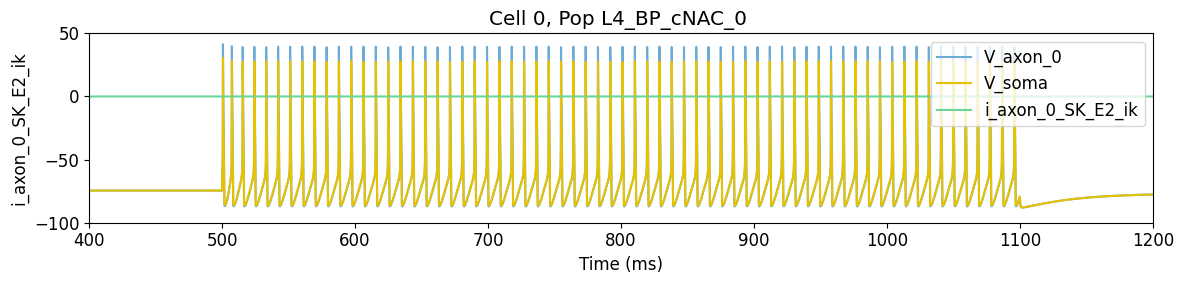

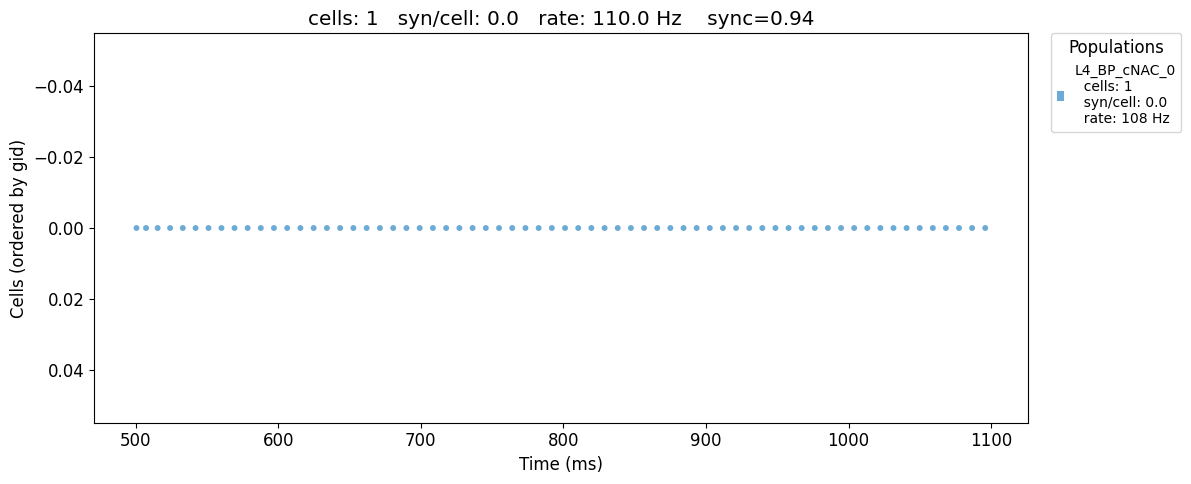

In [12]:
sim.gatherData();                  			# gather spiking data and cell info from each node
sim.saveData()                    			# save params, cell info and sim output to file (pickle,mat,txt,etc)#
sim.analysis.plotData()         			# plot spike raster etc

Preparing spike data...
Plotting raster...


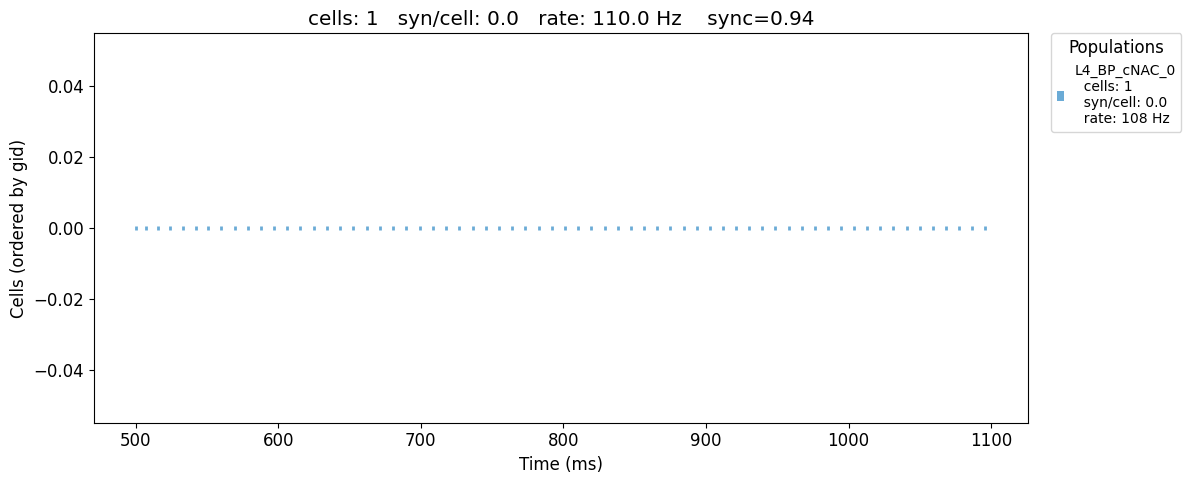

In [13]:
sim.analysis.plotRaster(include=cfg.Epops+cfg.Ipops, timeRange=[500,1100], figSize=(12,5), popRates=True);

In [14]:
import matplotlib.pyplot as plt

In [15]:
for pop in cfg.Epops[:3]:
  sim.analysis.plotTraces(include=[pop], timeRange=[580,600],ylim= [-100, 50], overlay=False, oneFigPer='cell', figSize=(18,3), showFig=False, saveFig=False);
  plt.grid(True)
for pop in cfg.Epops[3:]:
  sim.analysis.plotTraces(include=[pop], timeRange=[560,580],ylim= [-100, 50], overlay=False, oneFigPer='cell', figSize=(18,3), showFig=False, saveFig=False);
  plt.grid(True)
plt.show()

Plotting recorded cell traces ... trace


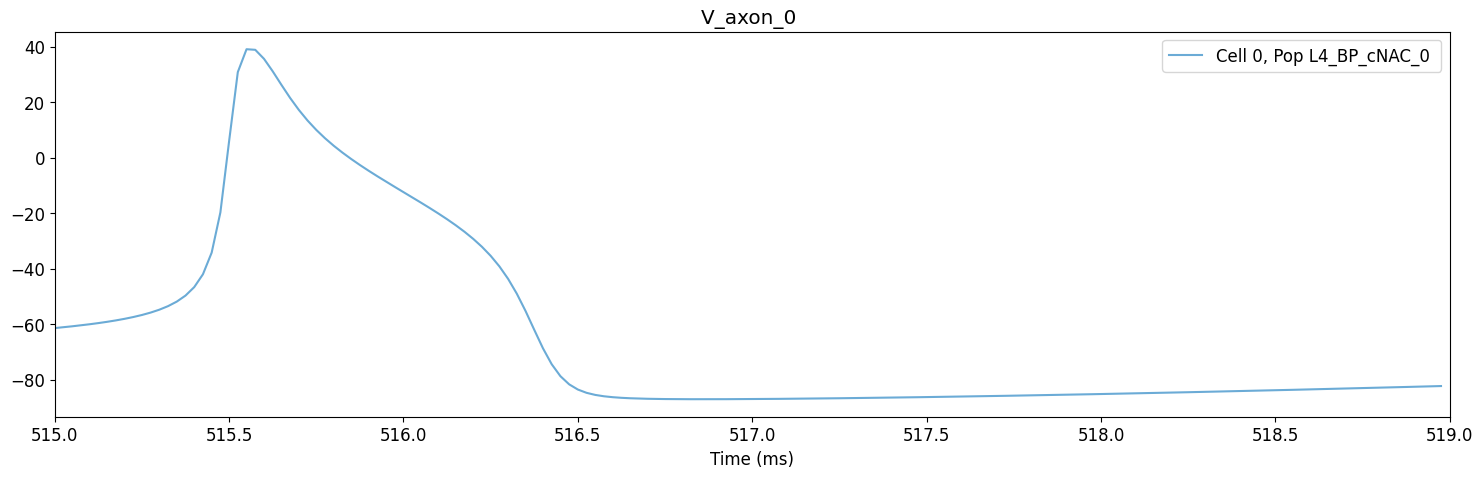

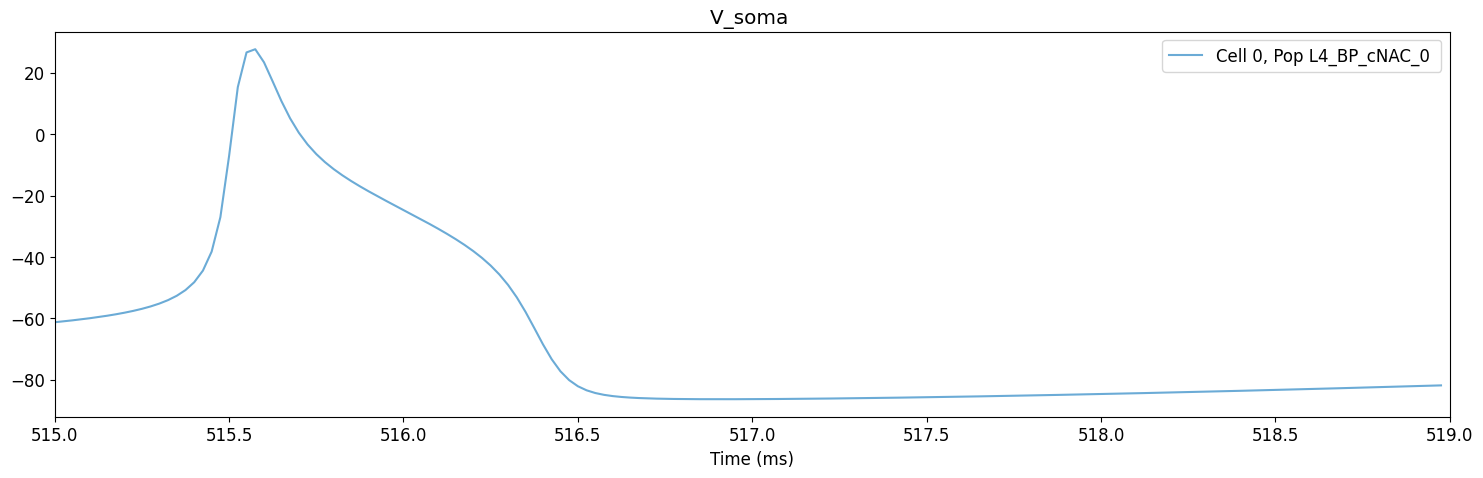

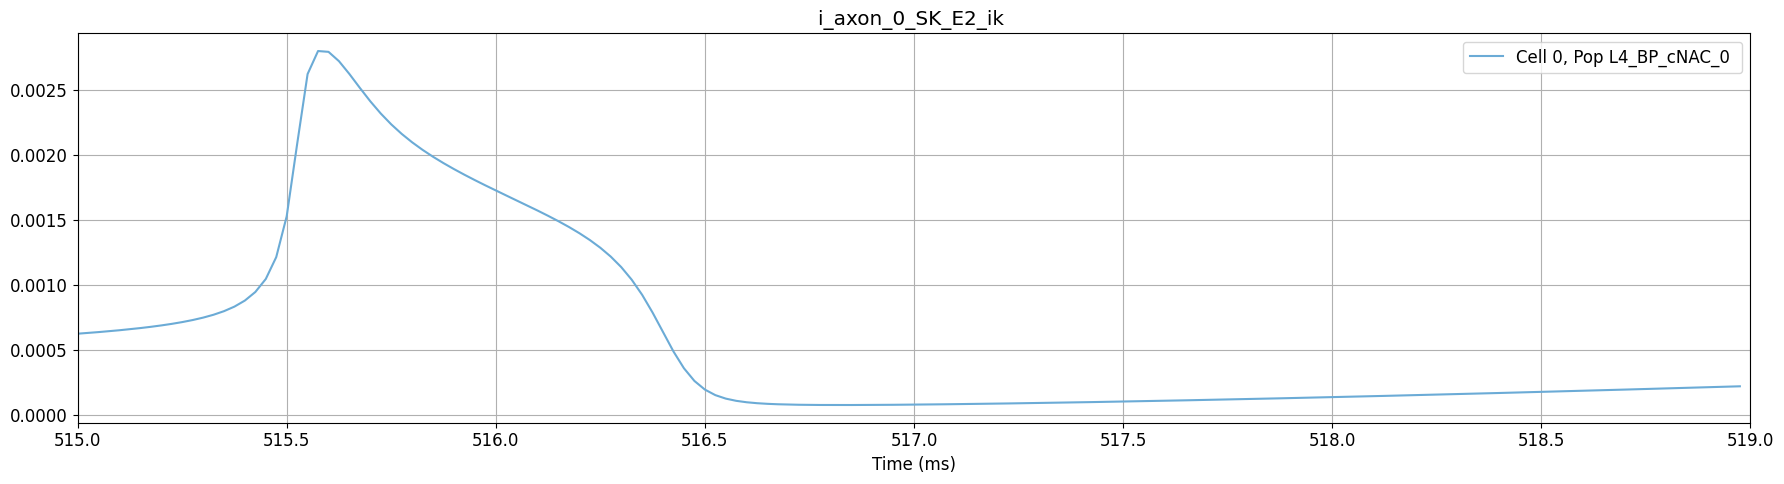

In [19]:
sim.analysis.plotTraces(include=cfg.Ipops[0:1], timeRange=[515,519], overlay=True, oneFigPer='trace', figSize=(18,5), showFig=False, saveFig=False);
plt.grid(True)
plt.show()

Plotting recorded cell traces ... cell


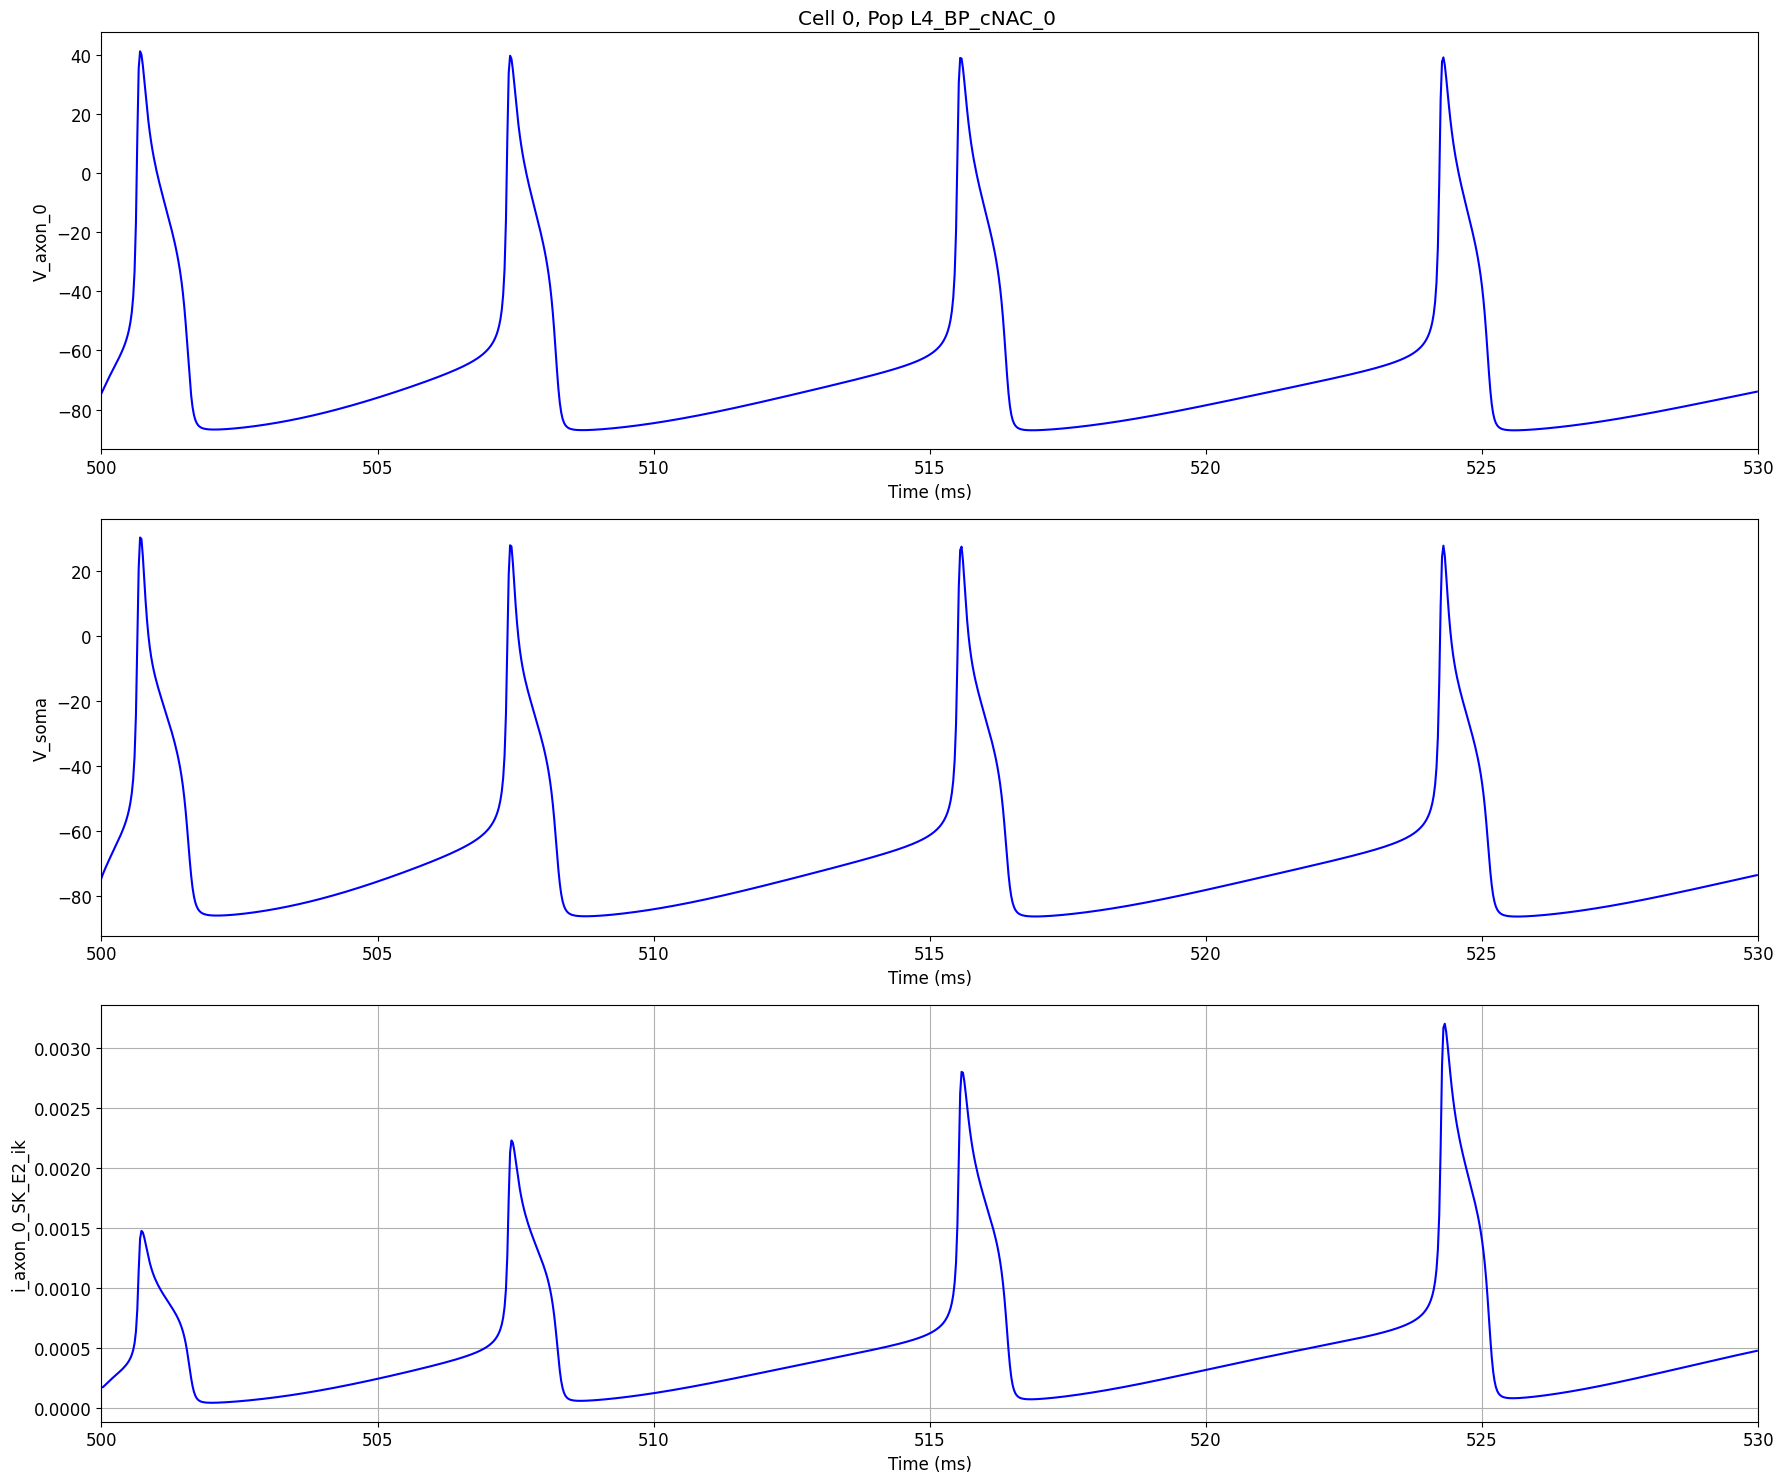

In [17]:
for pop in cfg.Ipops:
  sim.analysis.plotTraces(include=[pop], timeRange=[500,530], overlay=False, oneFigPer='cell', figSize=(18,15), showFig=False, saveFig=False);
  plt.grid(True)
plt.show()

Plotting recorded cell traces ... trace


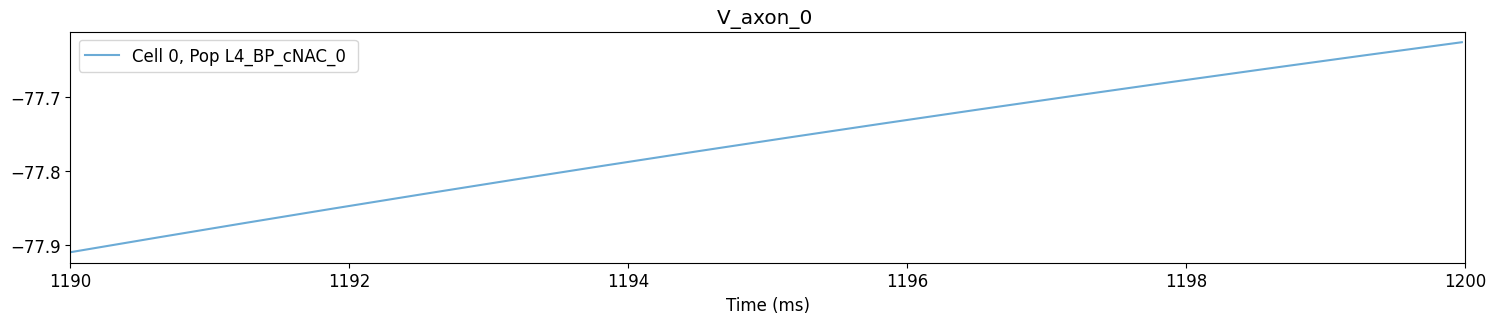

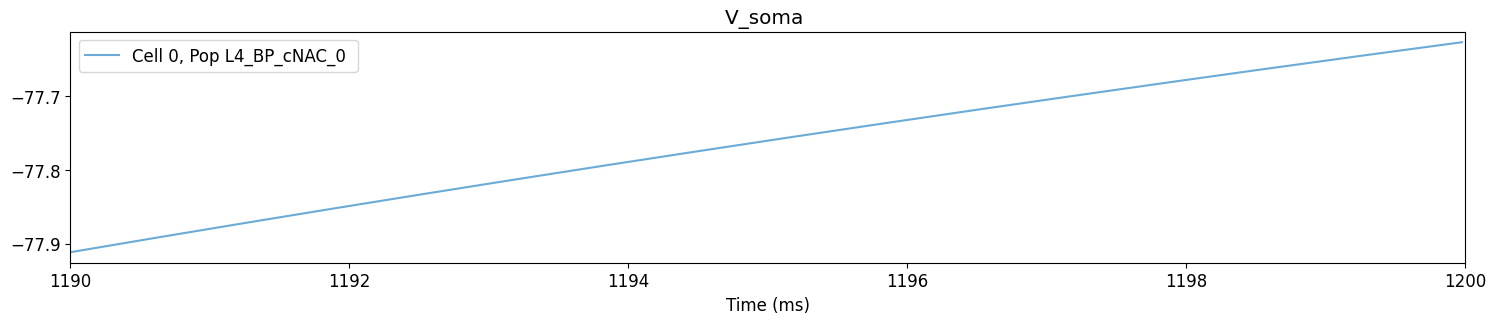

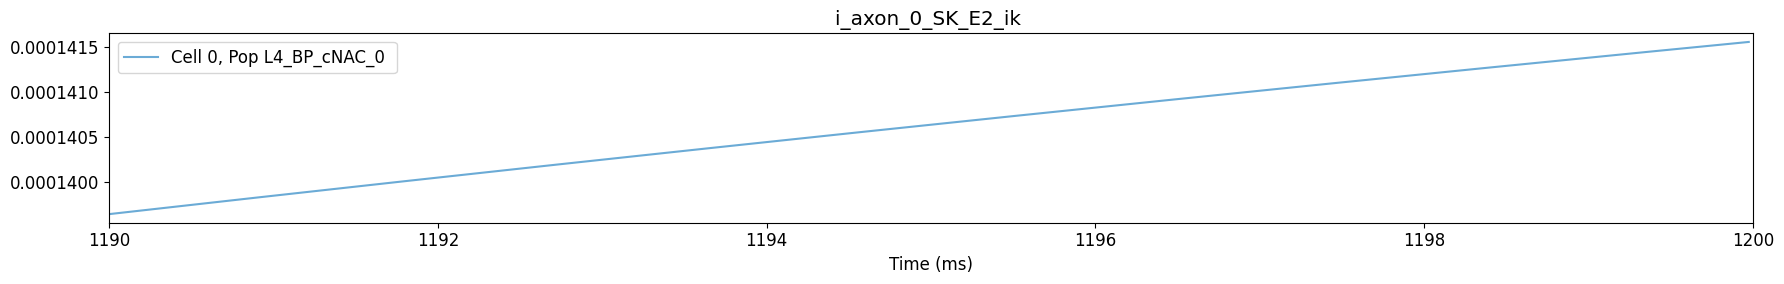

In [18]:
sim.analysis.plotTraces(include=cfg.Epops+cfg.Ipops, timeRange=[1190,1200], overlay=True, oneFigPer='trace', figSize=(18,3));